# Microfinance Loan Repayment Prediction

## 01 - Data Understanding

This project aims to develop a machine learning model that predicts the probability of a customer repaying a microfinance loan within the specified repayment period.

### Target Variable

- `1` → Non-defaulter / Loan repaid
- `0` → Defaulter / Loan not repaid

### Project Objective

To analyze customer and transaction-related information, identify useful patterns, engineer meaningful features, train multiple classification models, tune the best-performing models, and evaluate them using appropriate classification metrics such as Precision, Recall, F1-Score, ROC-AUC and Log Loss.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"

CSV_PATH = DATA_RAW / "Micro-credit-Data-file.csv"
DESCRIPTION_PATH = DATA_RAW / "Micro-credit-card-Data-Description.xlsx"

print("Project Root:")
print(PROJECT_ROOT)

print("\nCSV Path:")
print(CSV_PATH)

print("\nDescription File:")
print(DESCRIPTION_PATH)

Project Root:
c:\DOCUMENTS\INTRNFORTE\Microfinance_Loan_Repayment_Prediction

CSV Path:
c:\DOCUMENTS\INTRNFORTE\Microfinance_Loan_Repayment_Prediction\data\raw\Micro-credit-Data-file.csv

Description File:
c:\DOCUMENTS\INTRNFORTE\Microfinance_Loan_Repayment_Prediction\data\raw\Micro-credit-card-Data-Description.xlsx


In [4]:
print("CSV exists:", CSV_PATH.exists())
print("Description exists:", DESCRIPTION_PATH.exists())

CSV exists: True
Description exists: True


In [5]:
df = pd.read_csv(CSV_PATH)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully.
Rows    : 209,593
Columns : 37


In [6]:
df.head()

,Unnamed: 0,label,msisdn,aon,daily_decr30,daily_decr90,rental30,rental90,last_rech_date_ma,last_rech_date_da,last_rech_amt_ma,cnt_ma_rech30,fr_ma_rech30,sumamnt_ma_rech30,medianamnt_ma_rech30,medianmarechprebal30,cnt_ma_rech90,fr_ma_rech90,sumamnt_ma_rech90,medianamnt_ma_rech90,medianmarechprebal90,cnt_da_rech30,fr_da_rech30,cnt_da_rech90,fr_da_rech90,cnt_loans30,amnt_loans30,maxamnt_loans30,medianamnt_loans30,cnt_loans90,amnt_loans90,maxamnt_loans90,medianamnt_loans90,payback30,payback90,pcircle,pdate
0,1,0,21408I70789,272.0,3055.050000,3065.150000,220.13,260.13,2.0,0.0,1539,2,21.0,3078.0,1539.0,7.50,2,21,3078,1539.0,7.50,0.0,0.0,0,0,2,12,6.0,0.0,2.0,12,6,0.0,29.000000,29.000000,UPW,2016-07-20
1,2,1,76462I70374,712.0,12122.000000,12124.750000,3691.26,3691.26,20.0,0.0,5787,1,0.0,5787.0,5787.0,61.04,1,0,5787,5787.0,61.04,0.0,0.0,0,0,1,12,12.0,0.0,1.0,12,12,0.0,0.000000,0.000000,UPW,2016-08-10
2,3,1,17943I70372,535.0,1398.000000,1398.000000,900.13,900.13,3.0,0.0,1539,1,0.0,1539.0,1539.0,66.32,1,0,1539,1539.0,66.32,0.0,0.0,0,0,1,6,6.0,0.0,1.0,6,6,0.0,0.000000,0.000000,UPW,2016-08-19
3,4,1,55773I70781,241.0,21.228000,21.228000,159.42,159.42,41.0,0.0,947,0,0.0,0.0,0.0,0.00,1,0,947,947.0,2.50,0.0,0.0,0,0,2,12,6.0,0.0,2.0,12,6,0.0,0.000000,0.000000,UPW,2016-06-06
4,5,1,03813I82730,947.0,150.619333,150.619333,1098.90,1098.90,4.0,0.0,2309,7,2.0,20029.0,2309.0,29.00,8,2,23496,2888.0,35.00,0.0,0.0,0,0,7,42,6.0,0.0,7.0,42,6,0.0,2.333333,2.333333,UPW,2016-06-22


In [7]:
df.tail()

,Unnamed: 0,label,msisdn,aon,daily_decr30,daily_decr90,rental30,rental90,last_rech_date_ma,last_rech_date_da,last_rech_amt_ma,cnt_ma_rech30,fr_ma_rech30,sumamnt_ma_rech30,medianamnt_ma_rech30,medianmarechprebal30,cnt_ma_rech90,fr_ma_rech90,sumamnt_ma_rech90,medianamnt_ma_rech90,medianmarechprebal90,cnt_da_rech30,fr_da_rech30,cnt_da_rech90,fr_da_rech90,cnt_loans30,amnt_loans30,maxamnt_loans30,medianamnt_loans30,cnt_loans90,amnt_loans90,maxamnt_loans90,medianamnt_loans90,payback30,payback90,pcircle,pdate
209588,209589,1,22758I85348,404.0,151.872333,151.872333,1089.19,1089.19,1.0,0.0,4048,3,2.0,10404.0,3178.0,91.81,3,2,10404,3178.0,91.81,0.0,0.0,0,0,2,12,6.0,0.0,2.0,12,6,0.0,1.0,1.000000,UPW,2016-06-17
209589,209590,1,95583I84455,1075.0,36.936000,36.936000,1728.36,1728.36,4.0,0.0,773,4,1.0,3092.0,773.0,161.30,6,2,4038,773.0,111.80,0.0,0.0,0,0,3,18,6.0,0.0,3.0,18,6,0.0,1.0,1.000000,UPW,2016-06-12
209590,209591,1,28556I85350,1013.0,11843.111667,11904.350000,5861.83,8893.20,3.0,0.0,1539,5,8.0,9334.0,1539.0,51.13,11,5,18592,1539.0,47.13,0.0,0.0,0,0,4,42,12.0,0.0,6.0,54,12,0.0,4.0,3.833333,UPW,2016-07-29
209591,209592,1,59712I82733,1732.0,12488.228333,12574.370000,411.83,984.58,2.0,38.0,773,5,4.0,12154.0,773.0,164.00,6,4,17941,2410.5,100.00,0.0,0.0,1,0,2,18,12.0,0.0,3.0,24,12,0.0,0.0,10.500000,UPW,2016-07-25
209592,209593,1,65061I85339,1581.0,4489.362000,4534.820000,483.92,631.20,13.0,0.0,7526,2,1.0,9065.0,4532.5,356.70,3,19,16591,7526.0,392.20,0.0,0.0,0,0,2,18,12.0,0.0,2.0,18,12,0.0,0.0,0.000000,UPW,2016-07-07


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209593 entries, 0 to 209592
Data columns (total 37 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Unnamed: 0            209593 non-null  int64  
 1   label                 209593 non-null  int64  
 2   msisdn                209593 non-null  str    
 3   aon                   209593 non-null  float64
 4   daily_decr30          209593 non-null  float64
 5   daily_decr90          209593 non-null  float64
 6   rental30              209593 non-null  float64
 7   rental90              209593 non-null  float64
 8   last_rech_date_ma     209593 non-null  float64
 9   last_rech_date_da     209593 non-null  float64
 10  last_rech_amt_ma      209593 non-null  int64  
 11  cnt_ma_rech30         209593 non-null  int64  
 12  fr_ma_rech30          209593 non-null  float64
 13  sumamnt_ma_rech30     209593 non-null  float64
 14  medianamnt_ma_rech30  209593 non-null  float64
 15  medianmarec

In [9]:
print("Number of columns:", len(df.columns))

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

Number of columns: 37
01. Unnamed: 0
02. label
03. msisdn
04. aon
05. daily_decr30
06. daily_decr90
07. rental30
08. rental90
09. last_rech_date_ma
10. last_rech_date_da
11. last_rech_amt_ma
12. cnt_ma_rech30
13. fr_ma_rech30
14. sumamnt_ma_rech30
15. medianamnt_ma_rech30
16. medianmarechprebal30
17. cnt_ma_rech90
18. fr_ma_rech90
19. sumamnt_ma_rech90
20. medianamnt_ma_rech90
21. medianmarechprebal90
22. cnt_da_rech30
23. fr_da_rech30
24. cnt_da_rech90
25. fr_da_rech90
26. cnt_loans30
27. amnt_loans30
28. maxamnt_loans30
29. medianamnt_loans30
30. cnt_loans90
31. amnt_loans90
32. maxamnt_loans90
33. medianamnt_loans90
34. payback30
35. payback90
36. pcircle
37. pdate


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,209593.0,NaN,NaN,NaN,104797.0,60504.431823,1.0,52399.0,104797.0,157195.0,209593.0
label,209593.0,NaN,NaN,NaN,0.875177,0.330519,0.0,1.0,1.0,1.0,1.0
msisdn,209593,186243,04581I85330,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aon,209593.0,NaN,NaN,NaN,8112.343445,75696.082531,-48.0,246.0,527.0,982.0,999860.755168
daily_decr30,209593.0,NaN,NaN,NaN,5381.402289,9220.6234,-93.012667,42.44,1469.175667,7244.0,265926.0
daily_decr90,209593.0,NaN,NaN,NaN,6082.515068,10918.812767,-93.012667,42.692,1500.0,7802.79,320630.0
rental30,209593.0,NaN,NaN,NaN,2692.58191,4308.586781,-23737.14,280.42,1083.57,3356.94,198926.11
rental90,209593.0,NaN,NaN,NaN,3483.406534,5770.461279,-24720.58,300.26,1334.0,4201.79,200148.11
last_rech_date_ma,209593.0,NaN,NaN,NaN,3755.8478,53905.89223,-29.0,1.0,3.0,7.0,998650.377733
last_rech_date_da,209593.0,NaN,NaN,NaN,3712.202921,53374.83343,-29.0,0.0,0.0,0.0,999171.80941


In [11]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    "Missing_Count",
    ascending=False
)

missing_summary

,Missing_Count,Missing_Percentage
Unnamed: 0,0,0.0
label,0,0.0
msisdn,0,0.0
aon,0,0.0
daily_decr30,0,0.0
daily_decr90,0,0.0
rental30,0,0.0
rental90,0,0.0
last_rech_date_ma,0,0.0
last_rech_date_da,0,0.0


In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_count / len(df) * 100, 2), "%")

Duplicate rows: 0
Duplicate percentage: 0.0 %


In [13]:
TARGET = "label"

print("Target column:", TARGET)
print("\nTarget data type:")
print(df[TARGET].dtype)

print("\nTarget unique values:")
print(sorted(df[TARGET].unique()))

Target column: label

Target data type:
int64

Target unique values:
[np.int64(0), np.int64(1)]


In [14]:
target_counts = df[TARGET].value_counts().sort_index()

target_percentages = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_summary

,Count,Percentage
label,,
0,26162,12.48
1,183431,87.52


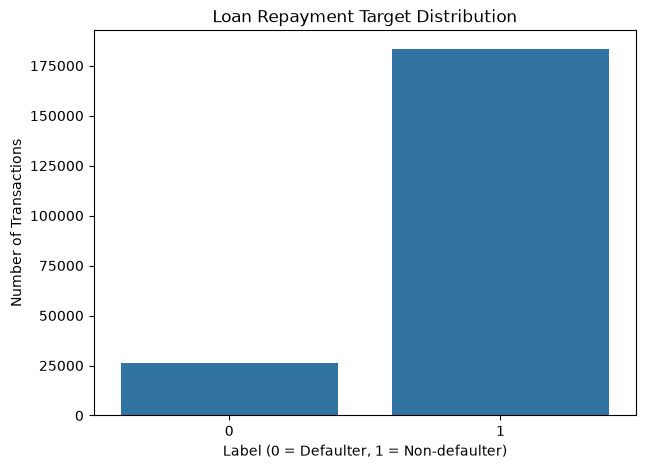

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Loan Repayment Target Distribution")
plt.xlabel("Label (0 = Defaulter, 1 = Non-defaulter)")
plt.ylabel("Number of Transactions")

plt.show()

In [16]:
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [df[col].nunique(dropna=False) for col in df.columns],
    "Data_Type": [df[col].dtype for col in df.columns]
})

unique_summary.sort_values(
    "Unique_Values",
    ascending=True
)

,Column,Unique_Values,Data_Type
35,pcircle,1,str
1,label,2,int64
31,maxamnt_loans90,3,int64
28,medianamnt_loans30,6,float64
32,medianamnt_loans90,6,float64
23,cnt_da_rech90,27,int64
25,cnt_loans30,40,int64
24,fr_da_rech90,46,int64
26,amnt_loans30,48,int64
30,amnt_loans90,69,int64


In [17]:
constant_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

print("Constant columns:")
print(constant_columns)

Constant columns:
['pcircle']


In [18]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Unnamed: 0', 'label', 'aon', 'daily_decr30', 'daily_decr90', 'rental30', 'rental90', 'last_rech_date_ma', 'last_rech_date_da', 'last_rech_amt_ma', 'cnt_ma_rech30', 'fr_ma_rech30', 'sumamnt_ma_rech30', 'medianamnt_ma_rech30', 'medianmarechprebal30', 'cnt_ma_rech90', 'fr_ma_rech90', 'sumamnt_ma_rech90', 'medianamnt_ma_rech90', 'medianmarechprebal90', 'cnt_da_rech30', 'fr_da_rech30', 'cnt_da_rech90', 'fr_da_rech90', 'cnt_loans30', 'amnt_loans30', 'maxamnt_loans30', 'medianamnt_loans30', 'cnt_loans90', 'amnt_loans90', 'maxamnt_loans90', 'medianamnt_loans90', 'payback30', 'payback90']

Categorical columns:
['msisdn', 'pcircle', 'pdate']


In [19]:
if "msisdn" in df.columns:
    print("Total records:", len(df))
    print("Unique customers:", df["msisdn"].nunique())
    print(
        "Records per unique customer:",
        round(len(df) / df["msisdn"].nunique(), 2)
    )

Total records: 209593
Unique customers: 186243
Records per unique customer: 1.13


In [20]:
summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "target": TARGET,
    "missing_cells": int(df.isnull().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "unique_customers": int(df["msisdn"].nunique()) if "msisdn" in df.columns else None
}

summary

{'rows': 209593,
 'columns': 37,
 'target': 'label',
 'missing_cells': 0,
 'duplicate_rows': 0,
 'unique_customers': 186243}

## Initial Data Understanding — Key Findings

The dataset contains 209,593 loan transaction records and 37 columns. The target variable is `label`, where 0 represents a defaulter and 1 represents a non-defaulter.

The target distribution is imbalanced, with substantially more non-defaulter transactions than defaulter transactions. Therefore, model evaluation should not rely only on accuracy.

The dataset contains 186,243 unique customers, indicating that some customers have multiple transaction records. This will be considered during data splitting and leakage analysis.

The dataset currently contains no missing values and no exact duplicate rows.

The dataset contains numerical, categorical, identifier, and date-related variables. Further investigation using the provided data dictionary is required before deciding which variables should be removed, transformed, or used for feature engineering.